# 第二部分 2.3：监督学习

| 章节 | 内容 |
|------|------|
| **2.5 线性模型** | 回归（线性/Ridge/Lasso/多项式）、分类（逻辑回归）|
| **2.6 树模型** | 决策树、随机森林、XGBoost |
| **2.7 支持向量机** | 硬间隔、软间隔、核函数 |

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_classification, make_regression, make_blobs, make_moons
from sklearn.model_selection import train_test_split

matplotlib.rcParams['font.family'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
print('环境就绪')

环境就绪


## 监督学习概览

监督学习的「分类方式」有两个维度，容易混淆：

### 维度一：按任务类型分（预测目标是什么）

| 任务 | 预测目标 | 典型例子 |
|------|----------|----------|
| **回归（Regression）** | 连续值 | 房价预测、温度预测、销量预测 |
| **分类（Classification）** | 离散标签 | 垃圾邮件判断、猫狗识别、信用评估 |

### 维度二：按模型族分（用什么结构的模型）

| 模型族 | 数学结构 | 能做回归？ | 能做分类？ |
|--------|----------|-----------|-----------|
| **线性模型** | 输出 = 特征的线性组合 | ✅ 线性回归、Ridge、Lasso | ✅ 逻辑回归 |
| **树模型** | 递归二分特征空间 | ✅ 回归树、随机森林回归 | ✅ 分类树、随机森林分类 |
| **支持向量机** | 最大化间隔超平面 | ✅ SVR | ✅ SVC |

> **关键认知**：两个维度互相独立。「线性模型」描述的是模型的数学结构，不是任务类型——线性模型既能做回归（线性回归），也能做分类（逻辑回归）。后续 2.5~2.7 均按**模型族**组织，每节内部再区分回归与分类用法。

## 2.5 线性模型

线性模型假设输出是输入特征的线性组合，是最简单也最常用的一类模型。优点：**可解释性强、训练快、可作为 baseline**。

---

### 用于回归任务

#### 线性回归（Linear Regression）

$$\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^\top \mathbf{x} + b$$

训练目标：最小化均方误差 $\text{MSE} = \frac{1}{n}\sum(y_i - \hat{y}_i)^2$

**单输出 vs 多输出**：需要同时预测多个目标值时（如温度、湿度、气压），变为**多输出回归**，权重矩阵 $W$ 变为 $m \times d$，$\hat{\mathbf{y}}$ 变为 $m$ 维向量。神经网络的每一个线性层本质上就是这个多输出形式。

#### 扩展到非线性：多项式回归

线性模型本身只能拟合直线。通过**特征工程**可以让它拟合曲线——把原始特征 $x$ 替换为一组新特征：

$$x \;\longrightarrow\; [x,\; x^2,\; x^3,\; \ldots]$$

然后对这组新特征做普通线性回归，得到**多项式回归**：

$$\hat{y} = w_1 x + w_2 x^2 + w_3 x^3 + b$$

**为什么明明有 $x^2$、$x^3$，还说"对参数是线性的"？**

关键在于：**"线性"描述的是 $\hat{y}$ 对权重 $w$ 的关系，不是对 $x$ 的关系。**

换一个视角——把 $x^2$ 和 $x^3$ 看作已经计算好的新特征，重新命名：

$$z_1 = x, \quad z_2 = x^2, \quad z_3 = x^3$$

模型变成：

$$\hat{y} = w_1 z_1 + w_2 z_2 + w_3 z_3 + b$$

这就是标准的线性回归形式——$w$ 都只以一次方出现，没有 $w^2$，没有 $w_1 \cdot w_2$，也没有 $e^w$。

训练时求解的正是这些 $w$，而 $z_1, z_2, z_3$ 是已知的输入数据，不是要优化的对象。所以从**优化角度**看，多项式回归和线性回归完全一样：同样可以用最小二乘法解析求解，同样可以用梯度下降，计算复杂度没有区别。

> **类比**：你去超市买水果，苹果 1 个、橙子 2 个、香蕉 3 个，要算总价。苹果价格、橙子价格、香蕉价格是"参数"（你要求的），个数是"特征"（已知）。不管个数是 1、2 还是 3 的平方，算总价的方式都是线性叠加。

非线性模型是指 $w$ 本身以非线性方式出现，例如 $\hat{y} = e^{w_1 x}$——这时就无法用线性代数方法直接求解了。

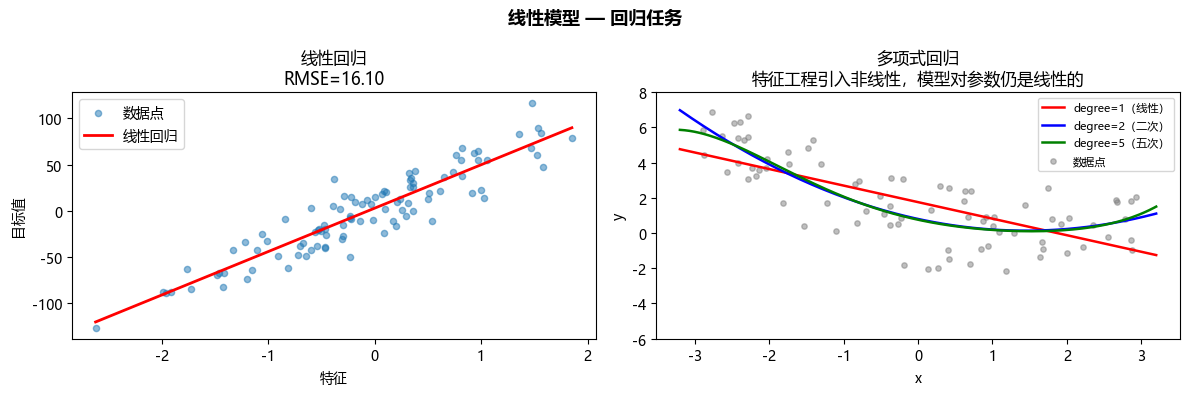

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('线性模型 — 回归任务', fontsize=13, fontweight='bold')

# ── 图1：线性回归 ─────────────────────────────────────────────
X_reg, y_reg = make_regression(n_samples=100, n_features=1, noise=20)
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2)
lr = LinearRegression().fit(X_tr, y_tr)
rmse = np.sqrt(mean_squared_error(y_te, lr.predict(X_te)))

x_line = np.linspace(X_reg.min(), X_reg.max(), 100).reshape(-1, 1)
axes[0].scatter(X_reg, y_reg, alpha=0.5, s=20, label='数据点')
axes[0].plot(x_line, lr.predict(x_line), 'r-', lw=2, label='线性回归')
axes[0].set_title(f'线性回归\nRMSE={rmse:.2f}')
axes[0].set_xlabel('特征')
axes[0].set_ylabel('目标值')
axes[0].legend()

# ── 图2：多项式回归（特征工程引入非线性） ────────────────────
np.random.seed(0)
X_poly = np.sort(np.random.uniform(-3, 3, 80))
y_poly = 0.5 * X_poly**2 - X_poly + np.random.randn(80) * 1.5
X_p = X_poly.reshape(-1, 1)

x_plot = np.linspace(-3.2, 3.2, 200).reshape(-1, 1)
for deg, color, label in [(1, 'red', 'degree=1（线性）'),
                           (2, 'blue', 'degree=2（二次）'),
                           (5, 'green', 'degree=5（五次）')]:
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression()).fit(X_p, y_poly)
    axes[1].plot(x_plot, model.predict(x_plot), color=color, lw=1.8, label=label)
axes[1].scatter(X_poly, y_poly, s=15, alpha=0.5, color='gray', label='数据点')
axes[1].set_title('多项式回归\n特征工程引入非线性，模型对参数仍是线性的')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend(fontsize=8)
axes[1].set_ylim(-6, 8)

plt.tight_layout()
plt.show()


### 用于分类任务

#### 逻辑回归（Logistic Regression）

名字里有"回归"，但它是**分类**模型。在线性输出上套一个 Sigmoid 函数，将结果压缩到 (0, 1) 作为概率：

$$P(y=1|\mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1+e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

训练目标：最小化**交叉熵损失**（等价于最大化对数似然）。

决策边界是特征空间中的一条**线性超平面**（2D 下是直线）。

> 模型输出的是**概率**（连续值），把概率 > 0.5 判为正类是人为加的后处理，不是模型本身。

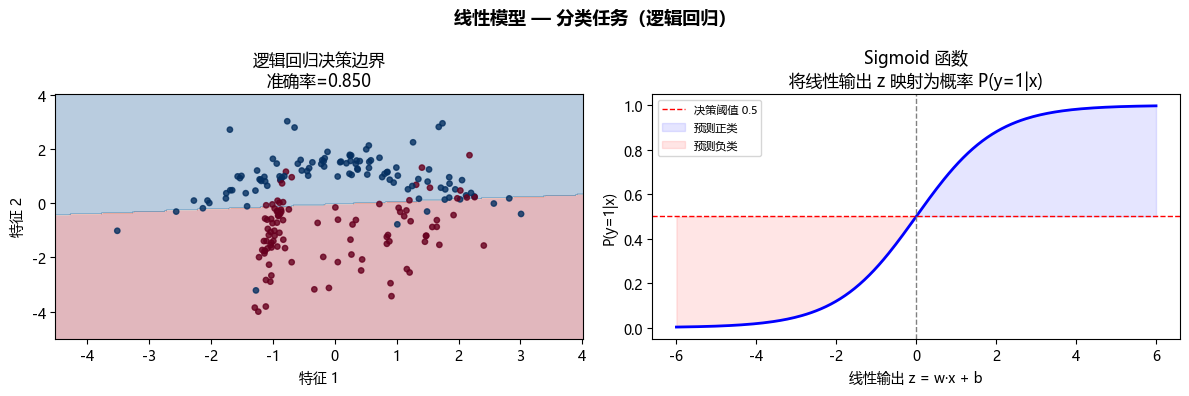

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('线性模型 — 分类任务（逻辑回归）', fontsize=13, fontweight='bold')

# ── 图1：逻辑回归决策边界 ─────────────────────────────────────
X_cls, y_cls = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                   n_informative=2, random_state=1)
X_tr, X_te, y_tr, y_te = train_test_split(X_cls, y_cls, test_size=0.2)
log_reg = LogisticRegression().fit(X_tr, y_tr)
acc = accuracy_score(y_te, log_reg.predict(X_te))

xx, yy = np.meshgrid(np.linspace(X_cls[:, 0].min() - 1, X_cls[:, 0].max() + 1, 200),
                     np.linspace(X_cls[:, 1].min() - 1, X_cls[:, 1].max() + 1, 200))
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
axes[0].scatter(X_cls[:, 0], X_cls[:, 1], c=y_cls, cmap='RdBu', s=15, alpha=0.8)
axes[0].set_title(f'逻辑回归决策边界\n准确率={acc:.3f}')
axes[0].set_xlabel('特征 1')
axes[0].set_ylabel('特征 2')

# ── 图2：Sigmoid 函数 ─────────────────────────────────────────
z = np.linspace(-6, 6, 200)
sigmoid = 1 / (1 + np.exp(-z))
axes[1].plot(z, sigmoid, 'b-', lw=2)
axes[1].axhline(0.5, color='r', linestyle='--', lw=1, label='决策阈值 0.5')
axes[1].axvline(0, color='gray', linestyle='--', lw=1)
axes[1].fill_between(z, sigmoid, 0.5, where=(sigmoid > 0.5), alpha=0.1, color='blue', label='预测正类')
axes[1].fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5), alpha=0.1, color='red', label='预测负类')
axes[1].set_title('Sigmoid 函数\n将线性输出 z 映射为概率 P(y=1|x)')
axes[1].set_xlabel('线性输出 z = w·x + b')
axes[1].set_ylabel('P(y=1|x)')
axes[1].legend(fontsize=8)
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()


## 2.6 树模型与集成学习

**决策树**是本节的基础学习器（base learner）。在此之上，**集成学习（Ensemble Learning）** 通过组合多个弱学习器来提升性能——基础学习器理论上可以是任何模型（SVM、逻辑回归等），本节选用决策树，因为它足够直观，且随机森林、XGBoost 等主流集成方法都以决策树为基础。

本节介绍三类模型：
- **单棵决策树**：基础，直观，容易过拟合
- **Bagging 集成（随机森林）**：并行训练多棵树，投票降低方差
- **Boosting 集成（AdaBoost / XGBoost）**：串行训练，逐步纠错

> 随机森林和 XGBoost 的本质是集成学习方法，之所以放在本节，是因为它们的基础学习器都是决策树。

---

### 实战数据集：Titanic 乘客生存预测

本节使用 seaborn 内置的 **泰坦尼克号乘客数据集** 贯穿所有模型对比。

| 属性 | 说明 |
|------|------|
| **来源** | 1912 年泰坦尼克号沉船事故乘客记录 |
| **规模** | 891 个样本，7 个特征 |
| **任务** | 二分类：存活（1）/ 遇难（0） |
| **类别比例** | 遇难 549（62%）/ 存活 342（38%），轻度不平衡 |
| **特征内容** | 船舱等级（pclass）、性别（sex）、年龄（age）、兄弟配偶数（sibsp）、父母子女数（parch）、票价（fare）、登船港口（embarked） |

**为什么选这个数据集？**
- seaborn 直接内置，一行加载，无需下载
- 特征含义直观，决策树的分裂规则完全符合常识（"女士优先"、头等舱优先逃生）
- 混合了连续特征（年龄、票价）和类别特征（性别、港口），贴近真实场景

---

### 决策树

每次从所有特征中选出**最优的切分特征和切分点**，把当前节点的样本一分为二，递归向下，直到叶节点只剩一种类别（分类）或方差足够小（回归）。

深度越深 → 模型越复杂 → 越容易过拟合。常用 `max_depth`、`min_samples_leaf` 限制树的生长。

#### 三种主流算法：ID3 → C4.5 → CART

决策树的核心问题是**如何选最优分裂特征**，三种算法代表了历史演进：

| 算法 | 分裂准则 | 主要特点 |
|------|---------|---------|
| **ID3**（1986） | 信息增益 | 切完之后两侧越"纯"越好，用香农熵衡量。缺陷：偏爱取值多的特征（极端情况下用"样本ID"分裂IG最大，但毫无泛化能力） |
| **C4.5**（1993） | 增益率 | 在信息增益上除以特征自身的熵，抑制高基数偏好；支持连续特征 |
| **CART**（1984） | Gini 不纯度 | 只生成**二叉树**；计算无对数、速度快；同时支持分类和回归；sklearn 默认算法 |

> **实践结论**：sklearn 的 `DecisionTreeClassifier` 使用 **CART**，理解 Gini 不纯度和二叉分裂就足够了。ID3 的信息熵直觉有助于理解"节点纯度"这个概念。C4.5 是过渡产物，了解即可。

  根节点特征选择：ID3 (信息增益) / C4.5 (增益率) / CART (Gini 减少量)

  Titanic：891 个样本，存活率 = 38.4%
  父节点  H(S)    = 0.9607   公式：H = -Σ P(c)·log₂P(c)
  父节点  Gini(S) = 0.4730   公式：Gini = 1 - Σ P(c)²

  ── 船舱等级（pclass），离散特征，3 种取值 ──
    ID3  IG = H(S) − ( 0.242×0.9510 + 0.207×0.9979 + 0.551×0.7989 )
            = 0.9607 − 0.8769 = 0.0838
    C4.5 IV = −(0.242·log₂0.242 + 0.207·log₂0.207 + 0.551·log₂0.551) = 1.4393
         GR = IG / IV = 0.0838 / 1.4393 = 0.0582
    CART 最优二分 pclass ≤ 2.5（编码值 [1, 2] vs [3]）：
         ΔGini = 0.4730 − 0.449×0.4934 − 0.551×0.3672 = 0.0491

  ── 性别（sex），离散特征，2 种取值 ──
    ID3  IG = H(S) − ( 0.352×0.8237 + 0.648×0.6992 )
            = 0.9607 − 0.7430 = 0.2177
    C4.5 IV = −(0.352·log₂0.352 + 0.648·log₂0.648) = 0.9362
         GR = IG / IV = 0.2177 / 0.9362 = 0.2325
    CART 最优二分 sex ≤ 0.5（编码值 [0] vs [1]）：
         ΔGini = 0.4730 − 0.352×0.3828 − 0.648×0.3064 = 0.1396

  ── 年龄（age），连续特征 ──
    ID3  最优阈值 age ≤ 6.50：
         IG = H(S) − wL·H(L) − wR·H(R)
            = 0.9607 −

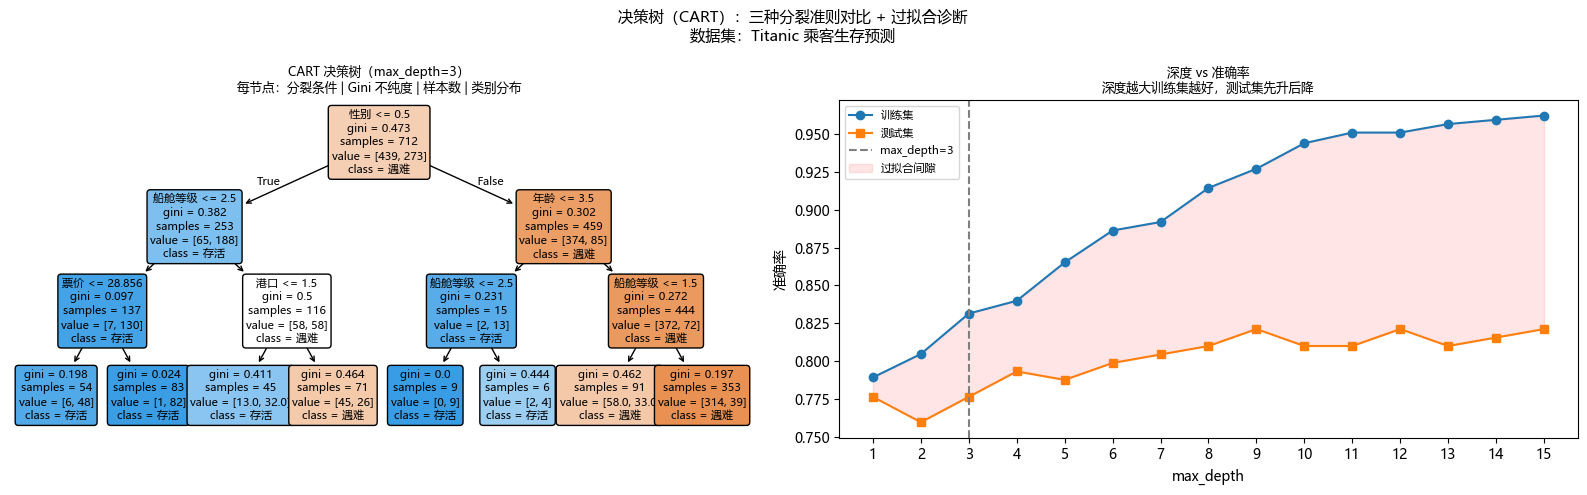

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ════════════════════════════════════════════════════════════════════
#  第一部分：根节点特征选择 —— ID3 / C4.5 / CART 三种算法对比
#
#  核心问题：对于根节点（第一次分裂），三种算法会各自选择哪个特征？
#  方法：手动计算每个特征在三种准则下的得分，最高分的特征即被选中
# ════════════════════════════════════════════════════════════════════

# ── 数据准备 ─────────────────────────────────────────────────────
raw = sns.load_dataset('titanic')
# 只保留 6 列：目标变量 survived + 5 个特征
df = raw[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].copy()

# 填充缺失值
df['age']      = df['age'].fillna(df['age'].median())   # age 有 177 个缺失，用中位数填
df['embarked'] = df['embarked'].fillna('S')             # embarked 只有 2 个缺失，用众数 'S' 填

# OrdinalEncoder 把字符串类别转成整数（决策树只接受数值输入）
# sex:      female → 0，male → 1
# embarked: C → 0，Q → 1，S → 2
df[['sex', 'embarked']] = OrdinalEncoder().fit_transform(df[['sex', 'embarked']])

y = df['survived'].values   # 标签数组：1=存活，0=遇难，共 891 个

# 特征列表：(列名, 中文名, 是否为连续特征)
# 连续特征（age/fare）需要枚举阈值做二分；离散特征（pclass/sex/embarked）可以直接按取值分组
features = [
    ('pclass',   '船舱等级', False),   # 3 个取值：1/2/3
    ('sex',      '性别',     False),   # 2 个取值：0(female)/1(male)
    ('age',      '年龄',     True),    # 连续值，需枚举切分点
    ('fare',     '票价',     True),    # 连续值，需枚举切分点
    ('embarked', '港口',     False),   # 3 个取值：0/1/2
]

# ── 三种准则的数学工具函数 ────────────────────────────────────

def H(y):
    """
    香农熵（Shannon Entropy）—— ID3 / C4.5 的纯度度量
    
    公式：H(S) = -Σ P(c) · log₂P(c)
    
    直觉：
      - 节点越"纯"（所有样本同类），熵越低（趋近 0）
      - 节点越"乱"（各类均匀分布），熵越高（二分类最大值 = 1.0）
    
    二分类简化：只需知道正类比例 p，负类比例自动为 1-p
      H = -(p·log₂p + (1-p)·log₂(1-p))
    """
    p = np.mean(y)                                          # 存活比例（正类比例）
    if p <= 0 or p >= 1: return 0.0                        # 纯节点：熵为 0
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

def Gini(y):
    """
    Gini 不纯度（Gini Impurity）—— CART 的纯度度量
    
    公式：Gini(S) = 1 - Σ P(c)²
    
    直觉：
      - 随机从节点取两个样本，两个样本类别不同的概率
      - 节点越纯，这个概率越低，Gini 越小（趋近 0）
      - 二分类最大值 = 0.5（各占 50% 时）
    
    二分类简化：Gini = 1 - (p² + (1-p)²) = 2p(1-p)
    """
    p = np.mean(y)
    return 2 * p * (1 - p)                                 # 二分类简化公式

def split_info(probs):
    """
    分裂信息量（Split Information / Intrinsic Value）—— C4.5 专用
    
    公式：IV(A) = -Σ |Sᵢ|/|S| · log₂(|Sᵢ|/|S|)
    
    作用：惩罚分支数多的特征，避免 ID3 偏好取值多的特征（如"样本ID"）
    
    直觉：
      - 把当前特征的分布本身当作一个"熵"来计算
      - 分支越多、越均匀 → IV 越大 → 增益率 GR = IG/IV 越小
      - 这样取值多的特征会被自动压低评分
    
    probs: 各子集的占比列表，如 [0.3, 0.7] 表示二分后左子集占30%、右子集占70%
    """
    return -sum(p * np.log2(p) for p in probs if p > 1e-12)   # 过滤掉 p=0 避免 log(0)

def best_binary(x, y, fn):
    """
    枚举所有可能的二分阈值，找到使「fn 减少量」最大的阈值
    
    用于连续特征（age、fare）和 CART 对离散特征的二分处理。
    
    CART 的核心设计之一：无论特征是连续还是离散，始终只做「二叉分裂」
    （而 ID3 对多值离散特征会做多路分裂，树可能变得很宽）
    
    阈值候选集：相邻两个不同取值的均值（即可能的最优切分点就在这些均值附近）
    例如 age 的取值有 [10, 20, 30, ...]，候选阈值就是 [15, 25, ...]
    
    参数：
      x:  特征列（一维数组）
      y:  标签列（一维数组）
      fn: 不纯度函数，传 H 则用于 ID3/C4.5，传 Gini 则用于 CART
    
    返回：(最优阈值 t, 对应的最大增益值)
    """
    uniq = np.sort(np.unique(x))                            # 所有不同取值，排序后才能生成相邻均值
    if len(uniq) < 2: return uniq[0], 0.0                  # 只有一个取值，无法分裂，增益为 0

    thresholds = (uniq[:-1] + uniq[1:]) / 2.0              # 相邻均值 = 候选阈值集合
    parent_impurity = fn(y)                                 # 分裂前父节点的不纯度
    best_t, best_g  = thresholds[0], -np.inf               # 初始化最优阈值和最大增益

    for t in thresholds:
        L, R = y[x <= t], y[x > t]                         # 按阈值 t 把样本分成左右两组
        if len(L) == 0 or len(R) == 0: continue            # 空节点无意义，跳过

        # 加权不纯度 = 左子集权重 × 左子集不纯度 + 右子集权重 × 右子集不纯度
        weighted = len(L)/len(y) * fn(L) + len(R)/len(y) * fn(R)
        gain = parent_impurity - weighted                   # 增益 = 父节点不纯度 - 分裂后加权不纯度

        if gain > best_g:
            best_g, best_t = gain, t                        # 更新最优

    return best_t, best_g

# ── 逐特征计算三种准则的得分 ──────────────────────────────────
print("=" * 74)
print("  根节点特征选择：ID3 (信息增益) / C4.5 (增益率) / CART (Gini 减少量)")
print("=" * 74)
print(f"\n  Titanic：{len(y)} 个样本，存活率 = {y.mean():.1%}")
print(f"  父节点  H(S)    = {H(y):.4f}   公式：H = -Σ P(c)·log₂P(c)")
print(f"  父节点  Gini(S) = {Gini(y):.4f}   公式：Gini = 1 - Σ P(c)²\n")

rows = []   # 汇总结果，格式：(中文名, 列名, IG, GR, ΔGini)

for feat, label, is_cont in features:
    x    = df[feat].values                  # 取出该特征的数据列
    uniq = np.sort(np.unique(x))            # 该特征的所有不同取值
    n    = len(y)                           # 总样本数（分母）

    print(f"  ── {label}（{feat}），{'连续特征' if is_cont else f'离散特征，{len(uniq)} 种取值'} ──")

    if is_cont:
        # ══════════════════════════════════════════════════════════
        # 连续特征处理策略：
        #   ID3 / C4.5：枚举阈值找使「信息增益」最大的切分点
        #   CART：      枚举阈值找使「Gini 减少量」最大的切分点
        # 注意：两者可能选出不同阈值（因为优化目标不同）
        # ══════════════════════════════════════════════════════════

        # ---- ID3 部分：最优二分阈值（按熵最小化）----
        t_e, ig  = best_binary(x, y, H)            # t_e = 最优阈值，ig = 最大信息增益
        L_e, R_e = y[x <= t_e], y[x > t_e]        # 按最优阈值分割后的左右子集标签
        wL, wR   = len(L_e)/n, len(R_e)/n          # 左右子集的样本占比（权重）

        # ---- C4.5 部分：在 ID3 的 IG 基础上除以 IV ----
        iv_val = split_info([wL, wR])              # 二分时只有 2 个子集，probs = [wL, wR]
        gr     = ig / iv_val if iv_val > 0 else 0.0   # 增益率 GR = IG / IV

        # ---- CART 部分：最优二分阈值（按 Gini 最小化）----
        t_g, gg  = best_binary(x, y, Gini)        # 独立搜索，和 ID3 的 t_e 可能不同
        L_g, R_g = y[x <= t_g], y[x > t_g]
        wLg, wRg = len(L_g)/n, len(R_g)/n

        # 打印逐步推导过程，方便对照公式验算
        print(f"    ID3  最优阈值 {feat} ≤ {t_e:.2f}：")
        print(f"         IG = H(S) − wL·H(L) − wR·H(R)")
        print(f"            = {H(y):.4f} − {wL:.3f}×{H(L_e):.4f} − {wR:.3f}×{H(R_e):.4f} = {ig:.4f}")
        print(f"    C4.5 IV  = −(wL·log₂wL + wR·log₂wR)   ← 分裂信息量，惩罚均匀二分")
        print(f"            = −({wL:.3f}·log₂{wL:.3f} + {wR:.3f}·log₂{wR:.3f}) = {iv_val:.4f}")
        print(f"         GR  = IG / IV = {ig:.4f} / {iv_val:.4f} = {gr:.4f}")
        print(f"    CART 最优阈值 {feat} ≤ {t_g:.2f}（可能与 ID3 阈值不同，因优化目标不同）：")
        print(f"         ΔGini = Gini(S) − wL·Gini(L) − wR·Gini(R)")
        print(f"               = {Gini(y):.4f} − {wLg:.3f}×{Gini(L_g):.4f} − {wRg:.3f}×{Gini(R_g):.4f} = {gg:.4f}")

    else:
        # ══════════════════════════════════════════════════════════
        # 离散特征处理策略（关键差异！）：
        #   ID3：多路分裂 —— 有几个取值就分成几个子集（可能分支数 > 2）
        #   C4.5：同 ID3 多路分裂，但增益率会惩罚分支多的特征
        #   CART：强制二叉分裂 —— 把取值分成两组，枚举最优分组方式
        # ══════════════════════════════════════════════════════════

        # ---- ID3 / C4.5 多路分裂部分 ----
        # 每个取值 v 对应一个子集，权重 = 该取值的样本数 / 总样本数
        counts  = np.array([np.sum(x == v) for v in uniq])   # 每个取值的样本数
        weights = counts / n                                    # 每个子集的权重
        subsets = [y[x == v] for v in uniq]                   # 每个子集的标签数组

        # 信息增益 IG = 父节点熵 - 各子集的加权熵之和
        ig = H(y) - sum(w * H(s) for w, s in zip(weights, subsets))

        # 分裂信息量 IV（多路分裂时分支多，IV 更大，会压低 GR）
        iv_val = split_info(weights)
        gr     = ig / iv_val if iv_val > 0 else 0.0

        # ---- CART 二叉分裂部分 ----
        # 对离散特征，CART 也只做二分：将取值分成「≤ 阈值」和「> 阈值」两组
        # 因为 OrdinalEncoder 编码后值是整数，这等价于把取值分成两个子集
        t_g, gg  = best_binary(x, y, Gini)
        L_g, R_g = y[x <= t_g], y[x > t_g]
        wLg, wRg = len(L_g)/n, len(R_g)/n
        left_vals  = [int(v) for v in uniq if v <= t_g]   # 编码后落在左边的取值
        right_vals = [int(v) for v in uniq if v >  t_g]   # 编码后落在右边的取值

        # 打印 ID3 多路分裂公式展开（显示每个子集的贡献）
        weighted_str = " + ".join(f"{w:.3f}×{H(s):.4f}" for w, s in zip(weights, subsets))
        print(f"    ID3  IG = H(S) − ( {weighted_str} )")
        print(f"            = {H(y):.4f} − {sum(w*H(s) for w,s in zip(weights,subsets)):.4f} = {ig:.4f}")

        # 打印 C4.5 IV 展开（显示每个分支的权重对 IV 的贡献）
        iv_str = " + ".join(f"{w:.3f}·log₂{w:.3f}" for w in weights)
        print(f"    C4.5 IV = −({iv_str}) = {iv_val:.4f}")
        print(f"         GR = IG / IV = {ig:.4f} / {iv_val:.4f} = {gr:.4f}")

        # 打印 CART 二叉分裂（显示编码值的分组方式）
        print(f"    CART 最优二分 {feat} ≤ {t_g:.1f}（编码值 {left_vals} vs {right_vals}）：")
        print(f"         ΔGini = {Gini(y):.4f} − {wLg:.3f}×{Gini(L_g):.4f} − {wRg:.3f}×{Gini(R_g):.4f} = {gg:.4f}")

    rows.append((label, feat, ig, gr, gg))    # 存入汇总列表
    print()

# ── 汇总对比表 ────────────────────────────────────────────────
print("=" * 74)
print(f"  {'特征':<14} {'ID3 信息增益':>14} {'C4.5 增益率':>13} {'CART ΔGini':>12}")
print("─" * 74)
for lbl, feat, ig, gr, gg in rows:
    print(f"  {lbl+'('+feat+')':<17} {ig:>13.4f} {gr:>13.4f} {gg:>12.4f}")
print("─" * 74)

# 找出每种准则下得分最高的特征（即根节点会被选中的特征）
b_id3  = max(rows, key=lambda r: r[2])    # IG 最大
b_c45  = max(rows, key=lambda r: r[3])    # GR 最大
b_cart = max(rows, key=lambda r: r[4])    # ΔGini 最大
print(f"\n  ★ ID3  根节点最优特征：{b_id3[0]}（IG    = {b_id3[2]:.4f}）")
print(f"  ★ C4.5 根节点最优特征：{b_c45[0]}（GR    = {b_c45[3]:.4f}）")
print(f"  ★ CART 根节点最优特征：{b_cart[0]}（ΔGini = {b_cart[4]:.4f}）")
if b_id3[1] == b_c45[1] == b_cart[1]:
    print(f"\n  → 三种算法在此数据集上均选「{b_id3[0]}」作为根节点首分裂特征")
else:
    print(f"\n  → 三种算法选择不同，体现了各准则对特征类型的偏好差异")
print(f"    提示：增益率 (GR) 会惩罚分支数多的特征（如港口 3 值 > 性别 2 值），")
print(f"          Gini 减少量无对数运算、计算更快，但三者的节点纯度直觉完全一致")

# ════════════════════════════════════════════════════════════════════
#  第二部分：sklearn CART 实战 —— 过拟合诊断
#
#  sklearn 的 DecisionTreeClassifier 内部使用 CART（criterion='gini'），
#  始终做二叉分裂，本部分演示 max_depth 对过拟合的控制作用
# ════════════════════════════════════════════════════════════════════

feat_names = ['船舱等级', '性别', '年龄', '票价', '港口']
X = df.drop('survived', axis=1).values                          # 特征矩阵，形状 (891, 5)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y            # stratify 保持训练/测试集的类别比例一致
)

# 训练两棵树：一棵不限深度（会过拟合），一棵限制到 3 层（泛化更好）
dt_deep    = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

print("\n" + "=" * 74)
print("  sklearn CART（criterion='gini'，二叉分裂）")
print("=" * 74)
for name, model in [('无限深度（过拟合）', dt_deep), ('max_depth=3（剪枝）', dt_shallow)]:
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test,  model.predict(X_test))
    print(f"  {name:<18}  训练={tr:.3f}  测试={te:.3f}  差距={tr-te:.3f}")
print()
print("  → 深树训练集接近完美，但把噪声也「记住」了，测试集反而更差")
print("    max_depth=3 限制生长（即剪枝），泛化能力更强")

# ── 可视化：树结构 + 过拟合曲线 ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 左图：打印 max_depth=3 的完整树结构
# filled=True：按多数类着色（蓝=存活，橙=遇难），颜色越深表示节点越纯
# impurity=True：在每个节点显示 Gini 值，可直观看到分裂后纯度提升
plot_tree(dt_shallow, ax=axes[0],
          feature_names=feat_names, class_names=['遇难', '存活'],
          filled=True, fontsize=8, impurity=True, rounded=True)
axes[0].set_title(
    'CART 决策树（max_depth=3）\n每节点：分裂条件 | Gini 不纯度 | 样本数 | 类别分布',
    fontsize=9
)

# 右图：扫描 depth=1~15，画出训练/测试准确率随深度的变化曲线
# 这张图完美展示了「偏差-方差权衡」：
#   - 深度太小（左侧）：欠拟合，训练和测试都差
#   - 深度太大（右侧）：过拟合，训练好但测试下降
#   - 最优深度在曲线的「拐点」附近
depths = range(1, 16)
train_accs, test_accs = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  m.predict(X_test)))

axes[1].plot(depths, train_accs, 'o-', label='训练集', color='C0')
axes[1].plot(depths, test_accs,  's-', label='测试集',  color='C1')
axes[1].axvline(3, color='gray', linestyle='--', lw=1.5, label='max_depth=3')
axes[1].fill_between(depths, train_accs, test_accs,
                     alpha=0.1, color='red', label='过拟合间隙')   # 红色填充区域 = 过拟合程度
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('准确率')
axes[1].set_title('深度 vs 准确率\n深度越大训练集越好，测试集先升后降', fontsize=9)
axes[1].legend(fontsize=8)
axes[1].set_xticks(list(depths))

plt.suptitle(
    '决策树（CART）：三种分裂准则对比 + 过拟合诊断\n数据集：Titanic 乘客生存预测',
    fontsize=11
)
plt.tight_layout()
plt.show()


### Bagging 集成（随机森林）

单棵决策树容易过拟合——深度无限制时，它会把训练集的每个噪声都"记住"。随机森林的思路是：**训练很多棵互不相同的树，用它们的集体投票代替单棵树的判断**。

两个"随机"的来源：
- **行采样（Bootstrap）**：每棵树只看训练集的一个随机子集（约 63%，有放回抽样）
- **列采样**：每次分裂时只从随机选取的一部分特征中挑最优切分点

两个随机让每棵树都"犯不同的错误"，投票之后错误相互抵消，整体泛化能力显著提升。这种「有放回抽样训练多个模型再集成」的策略叫做 **Bagging（Bootstrap Aggregating）**，随机森林是 Bagging 最经典的实现。

| | 决策树 | 随机森林 |
|--|--------|----------|
| 过拟合风险 | 高（深树记住噪声） | 低（集成平均平滑了噪声） |
| 可解释性 | 强（可打印整棵树） | 弱（几百棵树难以直接查看） |
| 特征重要性 | 支持 | 支持（更稳定） |
| 训练速度 | 快 | 较慢（树多，但可并行） |

- `n_estimators`：树的数量，越多越稳定，但有收益递减，通常 100~500 足够
- 每棵树的预测**并行**计算，可利用多核加速

### Boosting 集成

随机森林是**并行**训练一堆独立的树；Boosting 是**串行**训练，每棵新树专门拟合上一轮的**残差**（预测误差），一轮一轮地把错误修正掉。

```
第1棵树：预测结果，误差 = 真实值 - 预测值
第2棵树：专门学第1棵树的误差
第3棵树：专门学前两棵树加起来之后的剩余误差
……
最终预测 = 所有树的预测值加权求和
```

Boosting 是一大族算法，核心理念相同但机制不同：

#### AdaBoost（1996）

- **纠错方式**：每轮训练后，把**分错的样本权重调高**，下一棵树重点学这些难样本
- 弱学习器通常是深度 = 1 的**树桩（stump）**
- 最终预测 = 各棵树的**加权投票**（准确率高的树权重大）
- **缺点**：对噪声和离群点敏感，难样本权重不断放大可能导致过拟合噪声

#### GBDT / Gradient Boosting（2001）

- **纠错方式**：每棵新树直接拟合**损失函数的负梯度（即残差）**
- 可以优化任意可微的损失函数（MSE、交叉熵等），比 AdaBoost 更通用
- sklearn 的 `GradientBoostingClassifier` 是经典 GBDT 实现
- **缺点**：原版实现较慢，树只能串行构建，大数据集耗时长

#### XGBoost（2016）

- 同样是梯度提升，但做了大量工程优化：
  - 用**二阶泰勒展开**近似损失函数，梯度更新更精确
  - 内置 **L1/L2 正则化**，天然防过拟合
  - 支持**列采样**（借鉴随机森林），增加多样性
  - 树节点分裂**并行化**（虽然树仍串行，但单棵树的节点可并行计算）
  - 自动处理缺失值

#### LightGBM（2017，微软）

- 用**直方图分箱**替代精确搜索分裂点，速度比 XGBoost 快约 10×
- **叶优先生长**（leaf-wise）：每次分裂增益最大的叶，同样深度下精度更高
- 大规模数据集首选

---

**三种 Boosting 变体横向对比**：

| | AdaBoost | GBDT | XGBoost |
|--|---------|------|---------|
| 纠错方式 | 调高错误样本权重 | 拟合残差（一阶梯度） | 拟合残差（二阶梯度）+ 正则化 |
| 弱学习器 | 树桩（depth=1） | 较浅的树 | 较浅的树 |
| 过拟合风险 | 高（噪声敏感） | 中 | 低（内置正则化） |
| 实际使用 | 教学演示 | 理论基础 | 竞赛和生产主流 |

| | 随机森林（Bagging） | Boosting（XGBoost） |
|--|------------------|---------------------|
| 训练方式 | 并行，互相独立 | 串行，后树依赖前树 |
| 精度 | 好 | 通常更好 |
| 过拟合风险 | 低 | 较高，调参更重要 |
| 关键参数 | `n_estimators` | `n_estimators`、`learning_rate`、`max_depth` |

  集成学习对比：Titanic 生存预测
  总样本：891，训练集：712，测试集：179
  特征：['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
  存活率（训练集）：38.3%

模型                        训练准确率    测试准确率     F1   Recall(存活)  ROC-AUC   CV F1
----------------------------------------------------------------------------
决策树 (depth=3，浅树)          0.833    0.793  0.673        0.551    0.818   0.726
决策树 (无限深度，过拟合)            0.982    0.832  0.776        0.754    0.811   0.708
随机森林 (Bagging)            0.982    0.827  0.763        0.725    0.828   0.746
AdaBoost (Boosting)       0.829    0.782  0.698        0.652    0.825   0.725


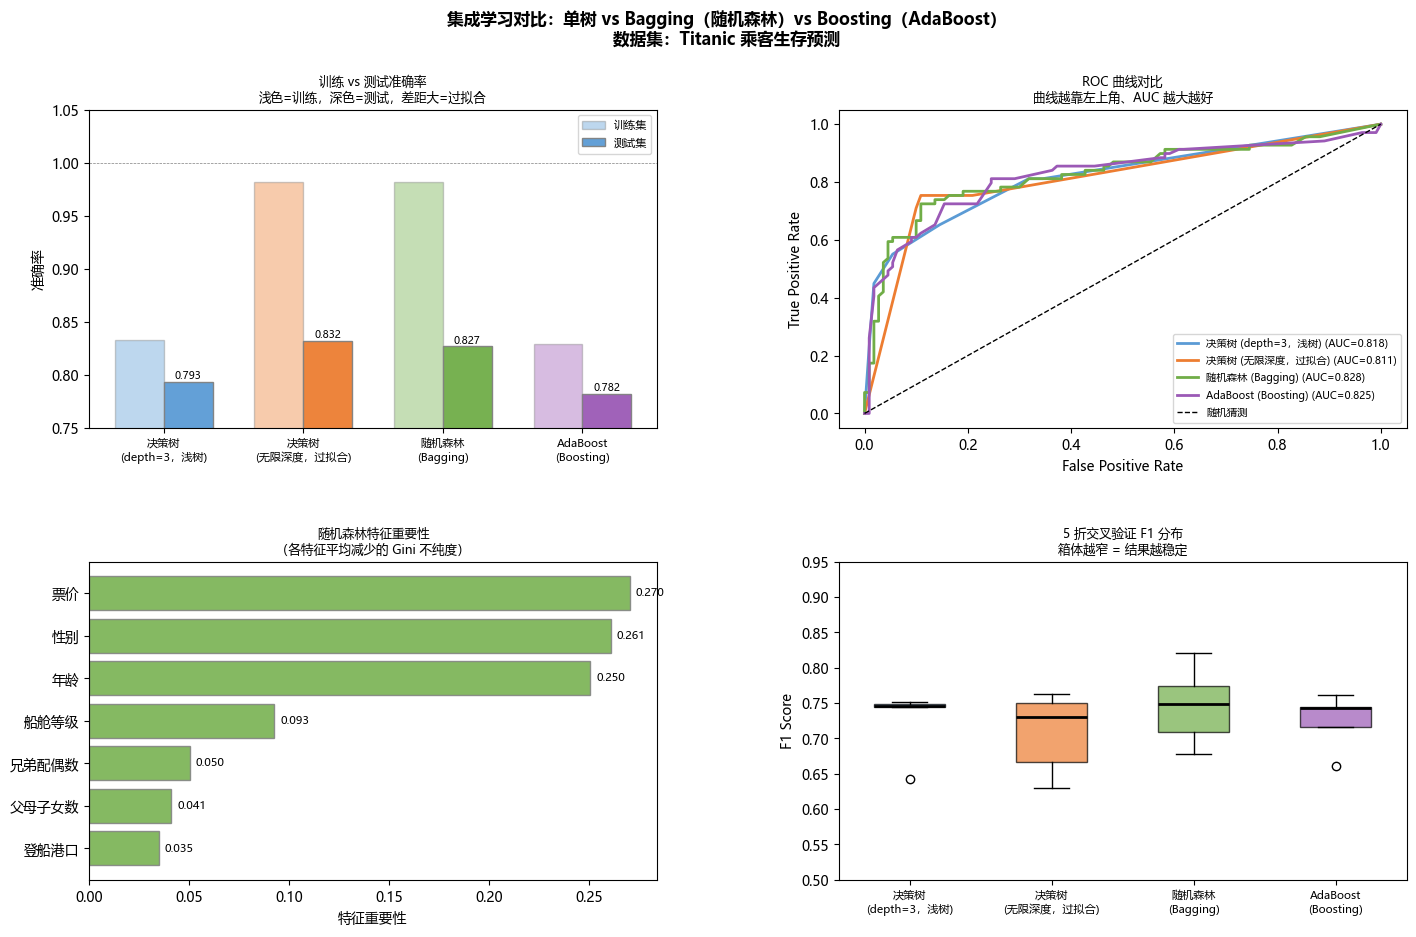


=== 关键观察 ===

1. 过拟合：深树训练=0.982 vs 测试=0.832（差距 0.149）
   浅树 depth=3 反而测试=0.793，说明限制深度能改善泛化
2. Bagging：随机森林 ROC-AUC=0.828，集成 100 棵树后比单棵稳定得多
3. Boosting：AdaBoost ROC-AUC=0.825，串行纠错策略在此数据集的表现

4. 特征重要性 Top3（随机森林）：
   票价（fare）= 0.270
   性别（sex）= 0.261
   年龄（age）= 0.250
   → 票价和年龄是最强信号（与历史一致：头等舱票价高、儿童优先）


In [9]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, roc_curve

# ══════════════════════════════════════════════════════════════════════
#  集成学习对比：单树 vs 随机森林（Bagging）vs Boosting
#  数据集：Titanic 生存预测（连续特征直接使用，无需离散化）
#
#  与上方 ID3 教学 cell 的区别：
#    - 这里保留 age、fare 等连续特征，更贴近真实 ML 使用场景
#    - 集成模型（随机森林、XGBoost）对连续特征天然支持，无需分箱
# ══════════════════════════════════════════════════════════════════════

# ── 数据准备（保留连续特征，简单填充缺失值）─────────────────
raw = sns.load_dataset('titanic')
df_ml = raw[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()

df_ml['age']      = df_ml['age'].fillna(df_ml['age'].median())
df_ml['embarked'] = df_ml['embarked'].fillna(df_ml['embarked'].mode()[0])
df_ml['sex']      = OrdinalEncoder().fit_transform(df_ml[['sex']])
df_ml['embarked'] = OrdinalEncoder().fit_transform(df_ml[['embarked']])

feature_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df_ml[feature_cols].values
y = df_ml['survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 64)
print("  集成学习对比：Titanic 生存预测")
print("=" * 64)
print(f"  总样本：{len(df_ml)}，训练集：{len(X_train)}，测试集：{len(X_test)}")
print(f"  特征：{feature_cols}")
print(f"  存活率（训练集）：{y_train.mean():.1%}\n")

# ── 定义 4 个模型 ─────────────────────────────────────────────
models = {
    '决策树\n(depth=3，浅树)':    DecisionTreeClassifier(max_depth=3, random_state=42),
    '决策树\n(无限深度，过拟合)': DecisionTreeClassifier(random_state=42),
    '随机森林\n(Bagging)':        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'AdaBoost\n(Boosting)':       AdaBoostClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        '训练准确率':    accuracy_score(y_train, model.predict(X_train)),
        '测试准确率':    accuracy_score(y_test, y_pred),
        'F1':           f1_score(y_test, y_pred),
        'Recall(存活)': recall_score(y_test, y_pred, pos_label=1),
        'ROC-AUC':      roc_auc_score(y_test, y_proba),
        'CV F1':        cross_val_score(model, X, y, cv=5, scoring='f1', n_jobs=-1).mean(),
        'proba':        y_proba,
    }

print(f"{'模型':<22} {'训练准确率':>8} {'测试准确率':>8} {'F1':>6} {'Recall(存活)':>12} {'ROC-AUC':>8} {'CV F1':>7}")
print("-" * 76)
for name, m in results.items():
    print(f"{name.replace(chr(10),' '):<22} {m['训练准确率']:>8.3f} {m['测试准确率']:>8.3f} "
          f"{m['F1']:>6.3f} {m['Recall(存活)']:>12.3f} {m['ROC-AUC']:>8.3f} {m['CV F1']:>7.3f}")

# ── 可视化（4 图）────────────────────────────────────────────
model_names = list(results.keys())
colors = ['#5B9BD5', '#ED7D31', '#70AD47', '#9B59B6']

fig = plt.figure(figsize=(17, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# 图1：训练 vs 测试准确率（过拟合诊断）
ax1 = fig.add_subplot(gs[0, 0])
x, w = np.arange(len(model_names)), 0.35
ax1.bar(x - w/2, [results[n]['训练准确率'] for n in model_names],
        width=w, label='训练集', color=colors, alpha=0.4, edgecolor='gray')
bars_te = ax1.bar(x + w/2, [results[n]['测试准确率'] for n in model_names],
                  width=w, label='测试集', color=colors, alpha=0.95, edgecolor='gray')
for bar in bars_te:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{bar.get_height():.3f}', ha='center', fontsize=7.5)
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, fontsize=8)
ax1.set_ylim(0.75, 1.05)
ax1.set_ylabel('准确率')
ax1.set_title('训练 vs 测试准确率\n浅色=训练，深色=测试，差距大=过拟合', fontsize=9)
ax1.legend(fontsize=8)
ax1.axhline(1.0, color='gray', lw=0.5, ls='--')

# 图2：ROC 曲线
ax2 = fig.add_subplot(gs[0, 1])
for name, c in zip(model_names, colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]['proba'])
    auc = results[name]['ROC-AUC']
    ax2.plot(fpr, tpr, lw=2, color=c, label=f"{name.replace(chr(10),' ')} (AUC={auc:.3f})")
ax2.plot([0,1],[0,1],'k--',lw=1,label='随机猜测')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC 曲线对比\n曲线越靠左上角、AUC 越大越好', fontsize=9)
ax2.legend(fontsize=7.5, loc='lower right')

# 图3：随机森林特征重要性
ax3 = fig.add_subplot(gs[1, 0])
rf_model      = models['随机森林\n(Bagging)']
importances   = rf_model.feature_importances_
feat_sorted   = sorted(zip(feature_cols, importances), key=lambda x: x[1], reverse=True)
feat_names_s  = [f for f, _ in feat_sorted]
feat_vals_s   = [v for _, v in feat_sorted]
feat_labels_cn = {'pclass':'船舱等级','sex':'性别','age':'年龄',
                  'sibsp':'兄弟配偶数','parch':'父母子女数',
                  'fare':'票价','embarked':'登船港口'}
feat_names_cn = [feat_labels_cn[f] for f in feat_names_s]

bars3 = ax3.barh(feat_names_cn, feat_vals_s, color='#70AD47', alpha=0.85, edgecolor='gray')
for bar, v in zip(bars3, feat_vals_s):
    ax3.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f'{v:.3f}', va='center', fontsize=8)
ax3.set_xlabel('特征重要性')
ax3.set_title('随机森林特征重要性\n（各特征平均减少的 Gini 不纯度）', fontsize=9)
ax3.invert_yaxis()

# 图4：5 折 CV F1 箱线图
ax4 = fig.add_subplot(gs[1, 1])
cv_all = {name: cross_val_score(model, X, y, cv=5, scoring='f1', n_jobs=-1)
          for name, model in models.items()}
bp = ax4.boxplot([cv_all[n] for n in model_names], patch_artist=True,
                 widths=0.5, medianprops=dict(color='black', lw=2))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax4.set_xticks(range(1, len(model_names)+1))
ax4.set_xticklabels(model_names, fontsize=8)
ax4.set_ylabel('F1 Score')
ax4.set_title('5 折交叉验证 F1 分布\n箱体越窄 = 结果越稳定', fontsize=9)
ax4.set_ylim(0.5, 0.95)

plt.suptitle('集成学习对比：单树 vs Bagging（随机森林）vs Boosting（AdaBoost）\n数据集：Titanic 乘客生存预测',
             fontsize=12, fontweight='bold')
plt.show()

# ── 关键观察 ──────────────────────────────────────────────────
print("\n=== 关键观察 ===\n")
dt_d = results['决策树\n(无限深度，过拟合)']
rf   = results['随机森林\n(Bagging)']
ada  = results['AdaBoost\n(Boosting)']
dt3  = results['决策树\n(depth=3，浅树)']

print(f"1. 过拟合：深树训练={dt_d['训练准确率']:.3f} vs 测试={dt_d['测试准确率']:.3f}"
      f"（差距 {dt_d['训练准确率']-dt_d['测试准确率']:.3f}）")
print(f"   浅树 depth=3 反而测试={dt3['测试准确率']:.3f}，说明限制深度能改善泛化")
print(f"2. Bagging：随机森林 ROC-AUC={rf['ROC-AUC']:.3f}，"
      f"集成 100 棵树后比单棵稳定得多")
print(f"3. Boosting：AdaBoost ROC-AUC={ada['ROC-AUC']:.3f}，"
      f"串行纠错策略在此数据集的表现")
print(f"\n4. 特征重要性 Top3（随机森林）：")
for fn, fv in feat_sorted[:3]:
    print(f"   {feat_labels_cn[fn]}（{fn}）= {fv:.3f}")
print(f"   → 票价和年龄是最强信号（与历史一致：头等舱票价高、儿童优先）")


## 2.7 支持向量机（SVM）

SVM 的目标是找到一个**间隔最大化**的超平面来分隔两类数据。

### 关键概念

- **支持向量（Support Vectors）**：距离决策边界最近的那些样本点，超平面位置完全由它们决定
- **间隔（Margin）**：两侧支持向量到决策边界的距离之和，SVM 最大化这个值
- **硬间隔**：要求所有点必须被正确分类（不允许误分类，只适合线性可分数据）
- **软间隔**：允许少量误分类，用参数 `C` 控制容忍程度
  - C 大 → 容忍度低 → 间隔小 → 更容易过拟合
  - C 小 → 容忍度高 → 间隔大 → 更简单的模型

### 核函数（Kernel Trick）

对于线性不可分的数据，通过核函数**隐式地将数据映射到高维空间**，在高维空间中找线性可分的超平面：

| 核函数 | 适用场景 |
|--------|----------|
| `linear` | 数据线性可分或特征维度很高 |
| `rbf`（高斯核） | 最常用，适合非线性问题 |
| `poly` | 多项式边界 |

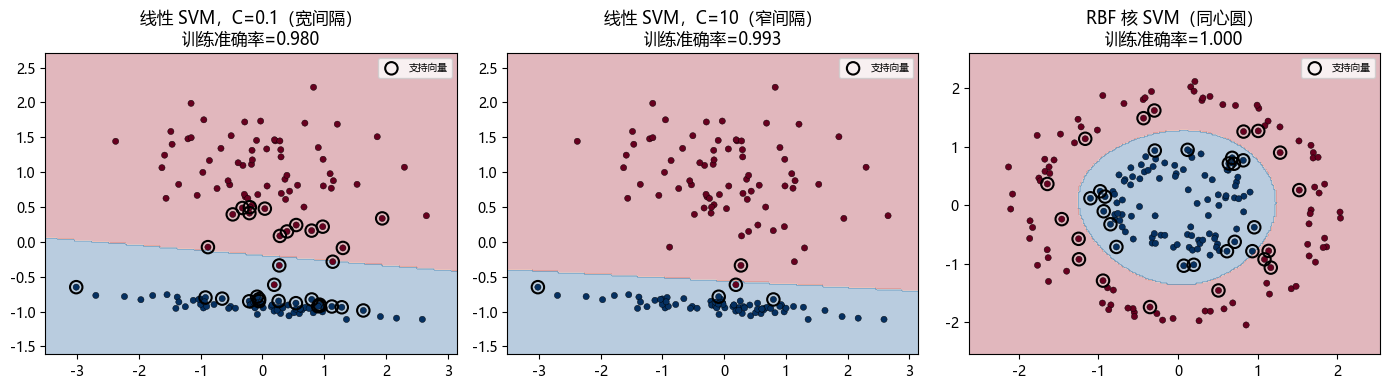

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)

def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='RdBu', s=20, edgecolors='k', linewidths=0.3)
    # 支持向量标记
    if hasattr(model, 'support_vectors_'):
        sv = model.support_vectors_
        ax.scatter(sv[:,0], sv[:,1], s=80, facecolors='none',
                   edgecolors='k', linewidths=1.5, label='支持向量')
    ax.set_title(title)
    ax.legend(fontsize=7)

# ── 数据准备 ──────────────────────────────────────────────────
# 线性可分数据
X_lin, y_lin = make_classification(n_samples=150, n_features=2, n_redundant=0,
                                   n_informative=2, n_clusters_per_class=1, random_state=1)
# 非线性数据（同心圆）
X_cir, y_cir = make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=42)

scaler = StandardScaler()
X_lin_s = scaler.fit_transform(X_lin)
X_cir_s = scaler.fit_transform(X_cir)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 线性 SVM（不同 C 值）
for ax, C, title in zip(axes[:2],
    [0.1, 10],
    ['线性 SVM，C=0.1（宽间隔）', '线性 SVM，C=10（窄间隔）']):
    model = SVC(kernel='linear', C=C).fit(X_lin_s, y_lin)
    acc = accuracy_score(y_lin, model.predict(X_lin_s))
    plot_decision_boundary(ax, model, X_lin_s, y_lin, f'{title}\n训练准确率={acc:.3f}')

# RBF 核 SVM（非线性）
rbf = SVC(kernel='rbf', C=1, gamma='scale').fit(X_cir_s, y_cir)
acc_rbf = accuracy_score(y_cir, rbf.predict(X_cir_s))
plot_decision_boundary(axes[2], rbf, X_cir_s, y_cir,
                       f'RBF 核 SVM（同心圆）\n训练准确率={acc_rbf:.3f}')

plt.tight_layout()
plt.show()